Домашнее задание. Логистическая регрессия и разные виды линейной регрессии (с регуляризацией)

Задача 1: Первичный анализ данных House Prices(1 балл)

Датасет: [House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview)

Требуется:

- Загрузите данные и выполните первичный анализ

- Проведите анализ распределения целевой переменной SalePrice

- Выявите и обработайте пропущенные значения в данных

In [641]:
! gdown 1SKx5Shx5J1O45mKBmjCtQmUF7LXRUou-

zsh:1: command not found: gdown


In [642]:
## Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge, LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score
import statsmodels


In [643]:
# читаем файлы
X = pd.read_csv('data/train.csv')
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [644]:
# описание признаков X
X.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [645]:
# a = X.columns[~(X.isnull().sum() == 0)].to_list()
# # b = X_train[X_train.isnull().sum() > 0]
# print(a)

In [646]:
# y - таргет
y = X['SalePrice']
X = X.drop(['SalePrice'], axis = 1)

In [647]:
# отдельно описание y_train_num
y.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

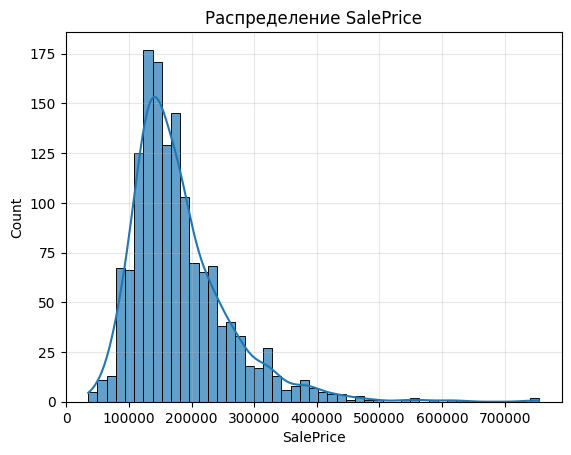

In [648]:
# гистограмма распределения y_num(saleprice)
y_np = np.array(y)
sns.histplot(y, bins = 'auto', kde=True, alpha = 0.7)
plt.title('Распределение SalePrice')
plt.grid(True, alpha=0.3)


<Axes: >

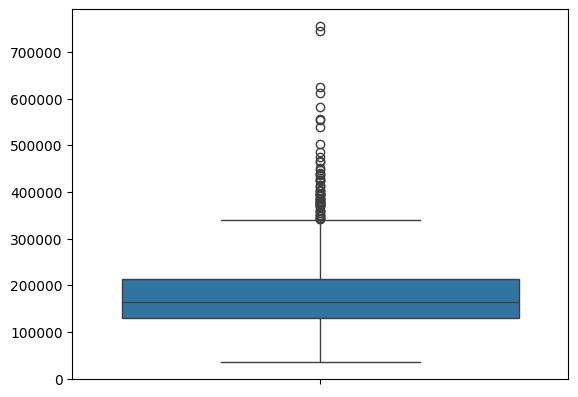

In [649]:
#boxplot для SalePrice
sns.boxplot(y_np)

Задача 2: Построение базовой модели (1 балл)

Требуется:

- Разделите данные на обучающую и тестовую выборки в соотношении 80/20

- Обучите модель LinearRegression на обучающей выборке, используя только числовые признаки

- Выберите метрику для сравнения моделей и обоснуйте свой выбор
- Рассчитайте свою метрику на тестовой выборке

In [650]:
# разделение данных на обучающую и тестовую выборки 
X_train, X_test, y_train, y_test = train_test_split(
                                                    X, y, test_size=0.2, 
                                                    random_state=42)

In [651]:
# выбрали признаки числовые и категориальные
num_feat = X.select_dtypes(include=['int64', 'float64']).columns
cat_feat = X.select_dtypes(include=['object']).columns

# создаем train, test выборку только с категориальными признаками
X_train_cat = X_train[cat_feat]
X_test_cat = X_test[cat_feat]

# создаем train, test выборку только с чисовыми признаками
X_train_num = X_train[num_feat]
X_test_num = X_test[num_feat]


In [652]:
# т.к в процентном соотношении пропусков не много заполняем их медианами
X_train_num= X_train_num.fillna(X_train_num.median()) 

X_test_num = X_test_num.fillna(X_train_num.median()) 

In [653]:
model_num = LinearRegression()
model_num.fit(X_train_num, y_train)

y_pred_num = model_num.predict(X_test_num)

print(f"r2_score: {r2_score(y_test, y_pred_num):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_num):.4f}")

r2_score: 0.8227
MSE: 1360318345.5164


Обоснование выбора метрики: я выбрал метрику r2_score, так как ее легче всего интерпретировать и она не зависит от едениц измерения. Это очень помогает например в сравнение моделей.

Задача 3: Предобработка данных и интерпретация модели (2 балл)

Требуется:

- Закодируйте категориальные переменные методами One-Hot Encoding или Label Encoding

- Масштабируйте числовые признаки с помощью StandardScaler

- Обучите LinearRegression на обучающих данных и оцените качество на тестовых данных по выбранной метрике

- Выведите 5 самых важных признаков по абсолютному значению коэффициентов

- Проанализируйте, какие факторы больше всего влияют на модель

Подсказка:
Зачем вообще нужен StandardScaler и One-Hot Encoding или Label Encoding ?

1) StandardScaler - для чего нужен:
- Нормализует масштаб числовых признаков (приводит к среднему=0, std=1)
- Зачем: Многие алгоритмы ML чувствительны к масштабу данных.
Пример проблемы: Признак "Площадь дома" (100-300 м²) и "Количество комнат" (1-5)без масштабирования алгоритм придаст больше веса площади, но после масштабирования - оба признака будут в одинаковом масштабе.

2) One-Hot Encoding/Label Encoding - для чего нужны:

- Label Encoding : Преобразует категории в числа. Сохраняет размерность данных, но может создать ложную порядковость (0 < 1 < 2)!

- One-Hot Encoding: Создает бинарные столбцы для каждой категории.Убирает ложную порядковость, но увеличивает размерность данных (проклятие размерности)

In [654]:
# если пропусков в котегорильных признаках больше чем 10%, то удаляем дропаем признак
# иначе заполняем пропуски модой
miss_feat = []
for col in X_train_cat.columns:
    if X_train_cat[col].isnull().mean() > 0.1:
        X_train_cat = X_train_cat.drop(col, axis = 1)
        X_test_cat = X_test_cat.drop(col, axis = 1)     
        miss_feat.append(col)
    else:
        X_train_cat[col] = X_train_cat[col].fillna(X_train_cat[col].mode()[0])
        X_test_cat[col] = X_test_cat[col].fillna(X_train_cat[col].mode()[0])


for col in X_train_cat.columns:
    if X_train_cat[col].isnull().mean() > 0:
        X_test_cat[col] = X_test_cat[col].fillna(X_train_cat[col].mode()[0])

print(miss_feat)

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


/var/folders/g3/vc1_40x50ng14k6mlk4l89wr0000gn/T/ipykernel_12244/1256369717.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_cat[col] = X_train_cat[col].fillna(X_train_cat[col].mode()[0])
/var/folders/g3/vc1_40x50ng14k6mlk4l89wr0000gn/T/ipykernel_12244/1256369717.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_cat[col] = X_test_cat[col].fillna(X_train_cat[col].mode()[0])


In [655]:
from sklearn.preprocessing import OneHotEncoder

# Создаем и обучаем энкодер на тренировочных данных
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat_enc= encoder.fit_transform(X_train_cat)
X_test_cat_enc = encoder.transform(X_test_cat)

#  преобразование обратно в dataframe:
feature_names = encoder.get_feature_names_out(X_train_cat.columns)
X_train_cat_enc = pd.DataFrame(X_train_cat_enc, columns=feature_names, index=X_train_cat.index)
X_test_cat_enc = pd.DataFrame(X_test_cat_enc, columns=feature_names, index=X_test_cat.index)

/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [13, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [656]:
# применяем StandardScaler к числовым признакам
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_num_std = scaler.fit_transform(X_train_num)
X_test_num_std = scaler.transform(X_test_num)

In [657]:
# Преобразуем numpy arrays обратно в DataFrame с сохранением названий колонок
X_train_num_std_df = pd.DataFrame(X_train_num_std, columns=X_train_num.columns, index=X_train_num.index)
X_test_num_std_df = pd.DataFrame(X_test_num_std, columns=X_test_num.columns, index=X_test_num.index)

# соединяем категориальные и числовые признаки
X_train_all = pd.concat([X_train_num_std_df, X_train_cat_enc], axis=1)
X_test_all = pd.concat([X_test_num_std_df, X_test_cat_enc], axis=1)  

In [658]:
model_all = LinearRegression()
model_all.fit(X_train_all, y_train)

y_pred = model_all.predict(X_test_all)

print(f"r2_score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

r2_score: 0.6476
MSE: 2703279640.9618


In [659]:
coef_df = pd.DataFrame({
    'feature': X_train_all.columns,
    'coef': model_all.coef_
})
top_5 = coef_df.reindex(coef_df.coef.abs().sort_values(ascending=False).index).head(5)
print(top_5)

              feature           coef
111    RoofMatl_Metal  714787.706954
115  RoofMatl_WdShngl  680497.660813
113  RoofMatl_Tar&Grv  672710.727791
112     RoofMatl_Roll  672683.509241
114  RoofMatl_WdShake  671427.378649


Выводы: Модель показала не самое лучшее качество — значение r2_score = 0.6476, что говорит о довольно сабой предсказательной силе. Кроме того, у некоторых малозначимых признаков оказались очень большие веса. Скорее всего, это из-за мультиколлинеарности, которую мог вызвать One-Hot Encoding. 

Задача 4: Регуляризация и подбор гиперпараметров (1 балл)

Требуется:

- Создайте Pipeline с MinMaxScaler и ElasticNet, подберите оптимальные параметры (alpha, l1_ratio) с помощью GridSearchCV

- Создайте Pipeline с StandardScaler и ElasticNet, подберите оптимальные параметры (alpha, l1_ratio) с помощью GridSearchCV

- Для оценки качества используйте выбранную ранее метрику

### Pipeline с MinMaxScaler и ElasticNet

In [660]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline с MinMaxScaler
pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('elasticnet', ElasticNet(random_state=42))
])

# Параметры для подбора
param_grid = {
    'elasticnet__alpha': [0.001, 0.01, 0.1, 1, 10],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Поиск лучших параметров
grid_minmax = GridSearchCV(pipe_minmax, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_minmax.fit(X_train_all, y_train)

print(" MinMaxScaler и ElasticNet")
print("Лучшие параметры:", grid_minmax.best_params_)
print("Лучший r2_score на кросс-валидации:", grid_minmax.best_score_)

# Оценка на тестовых данных
y_pred_minmax = grid_minmax.predict(X_test_all)
r2_minmax = r2_score(y_test, y_pred_minmax)
print("r2_score на тестовых данных:", r2_minmax)

# Зануленные признаки
best_minmax = grid_minmax.best_estimator_.named_steps['elasticnet']
zero_coefs_minmax = sum(best_minmax.coef_ == 0)
print(f"Занулено признаков: {zero_coefs_minmax}")


/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.827e+09, tolerance: 5.374e+08
  model = cd_fast.enet_coordinate_descent(
/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.104e+08, tolerance: 5.716e+08
  model = cd_fast.enet_coordinate_descent(
/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

 MinMaxScaler и ElasticNet
Лучшие параметры: {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.1}
Лучший r2_score на кросс-валидации: 0.8301167165689639
r2_score на тестовых данных: 0.8598643491906355
Занулено признаков: 0


### Pipeline с StandardScaler и ElasticNet

In [661]:

# Pipeline с StandardScaler
pipe_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(random_state=42))
])

grid_standard = GridSearchCV(pipe_standard, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_standard.fit(X_train_all, y_train)

print("StandardScaler и ElasticNet")
print("Лучшие параметры:", grid_standard.best_params_)
print("Лучший r2_score на кросс-валидации:", grid_standard.best_score_)

# Оценка на тестовых данных
y_pred_standard = grid_standard.predict(X_test_all)
r2_standard = r2_score(y_test, y_pred_standard)
print("r2_score на тестовых данных:", r2_standard)

# Зануленные признаки
best_standard = grid_standard.best_estimator_.named_steps['elasticnet']
zero_coefs_standard = sum(best_standard.coef_ == 0)
print(f"Занулено признаков: {zero_coefs_standard}")


/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.697e+11, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(
/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.701e+11, tolerance: 5.256e+08
  model = cd_fast.enet_coordinate_descent(
/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of 

StandardScaler и ElasticNet
Лучшие параметры: {'elasticnet__alpha': 1, 'elasticnet__l1_ratio': 0.5}
Лучший r2_score на кросс-валидации: 0.809034287922606
r2_score на тестовых данных: 0.8565690062778738
Занулено признаков: 0


### Сравнение результатов

In [662]:
print("Сравнение")
print(f"LinearRegression: {r2_score(y_test, y_pred):.4f}")
print(f"MinMax и ElasticNet: {r2_score(y_test, y_pred_minmax):.4f}")
print(f"Standard и ElasticNet: {r2_score(y_test, y_pred_standard):.4f}")


Сравнение
LinearRegression: 0.6476
MinMax и ElasticNet: 0.8599
Standard и ElasticNet: 0.8566


### Анализ коэффициентов лучшей модели

In [663]:
# коэффициенты модели MinMax
best_elasticnet = grid_minmax.best_estimator_.named_steps['elasticnet']

coef_df = pd.DataFrame({
    'feature': X_train_all.columns,
    'coefficient': best_elasticnet.coef_
})

# 10 самых важных признаков
top_10 = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(10)
print("10 самых важных признаков MinMax и ElasticNet:")
print(top_10)

10 самых важных признаков MinMax и ElasticNet:
                  feature   coefficient
4             OverallQual  50171.773032
16              GrLivArea  39725.099796
14               2ndFlrSF  39060.935127
23           TotRmsAbvGrd  35002.288447
69   Neighborhood_NoRidge  33535.417492
76   Neighborhood_StoneBr  30995.966429
26             GarageCars  30172.343465
13               1stFlrSF  29035.830447
19               FullBath  28558.136354
191        KitchenQual_TA -25541.648672


Вопросы для анализа:(1 балл)

1. Сравните оптимальные параметры в двух экспериментах

2. Сравните качество модели на тестовой выборке в обоих случаях

3. Проанализируйте, какие признаки были занулены в каждом эксперименте и объясните возможные причины

4. Сделайте вывод о влиянии типа масштабирования на качество линейной регрессии

Ответ на вопрос: 
1) Alpha: StandardScaler требует в 100 раз более сильной регуляризации (a=1 vs a=0.01)
    L1_ratio: MinMax предпочел в основном L2 регуляризацию (0.1), StandardScaler - равный вклад (0.5)

2) Обе регуляризованные модели значительно лучше обычной. Между собой почти не отличаются, но MinMaxScaler показывает немного лучшее качество
3) Никакие признаки не были занулены, так как обе модели использовали L2 регуляризацию, которая не обнуляет веса
4) В моем случае тип масшабирования не значимо повлиял на качество линейной регрессии


Задача 5: Бинарная классификация с помощью логистической регрессии (2 балла)

Требуется:

- Создайте бинарную целевую переменную expensive (1 - если цена выше медианы, 0 - в противном случае)

- Обучите модель LogisticRegression с L2-регуляризацией

- Выполните подбор гиперпараметров с помощью GridSearchCV

- Оцените качество модели с помощью метрики F1-score

- Для лучшей модели выведите Топ-5 самых важных признаков

Примечание: Не забудьте разделить данные на обучающую и тестовую выборки перед обучением модели с тем же random_state.

In [664]:


#Создаем бинарную целевую переменную из исходного y
y_binary = (y > y.median()).astype(int)

# Разделяем на train/test 
y_train_binary = y_binary[X_train_all.index]
y_test_binary = y_binary[X_test_all.index]

# Создаем пайплайн
pipe_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(penalty='l2', random_state=42))
])

# Параметры
param_grid = {
    'logistic__C': [0.001, 0.01, 0.1, 1, 10, 100]  # C = 1/alpha
}

# Ищем лучшие параметры
grid_logistic = GridSearchCV(pipe_logistic, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_logistic.fit(X_train_all, y_train_binary)

# Оценка качества
y_pred = grid_logistic.predict(X_test_all)
print("F1-score:", f1_score(y_test_binary, y_pred))

# 5 самых важных признаков
best_logistic = grid_logistic.best_estimator_.named_steps['logistic']

coef_df = pd.DataFrame({
    'feature': X_train_all.columns,
    'coefficient': best_logistic.coef_[0]
})

top_5 = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(5)
print("5 самых важных признаков:")
print(top_5)

F1-score: 0.9552238805970149
5 самых важных признаков:
        feature  coefficient
19     FullBath     0.288111
24   Fireplaces     0.271163
16    GrLivArea     0.267773
4   OverallQual     0.244642
26   GarageCars     0.217611


/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/romanananev/Desktop/tink/ML/MLvenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-le

Проанализируй все модели и ответе на вопросы :(2 балла)

1) Какая модель показала наилучшие результаты для регрессии и почему?

2) Как регуляризация повлияла на веса признаков?

3) Какие признаки оказались наиболее важными для предсказания цены дома?

4) Насколько хорошо логистическая регрессия справилась с бинарной классификацией?

5) Какие проблемы в данных могли повлиять на качество моделей?

Ответ на вопросы:
1) Лучший результат показали модель MinMaxScaler + ElasticNet, так как r2_score = 0.86 - самый высокий из моделей. Это связано с тем, что у этой модели была оптимальная, не очень строгая регуляризация и это хорошо подошло к данным о недвижимости
2) Устранила проблему огромных коэффициентов (были десятки тысяч). 
   Стабилизировала веса - сделала их разумными и интерпретируемыми
3) Для регрессии: Общее качество, жилая площадь, площадь второго этажа, элитный район, размер гаража. 
    Для классификации: количество ванных, камины,  жилая площадь, гараж, качество
4) Логистическая регрессия справилась с бинарной классификацией очень хорошо, метрика F1-score = 0.955. Почти идеальное разделение на дорогие/дешевые дома
5) 1. Мультиколлинеарность от One-Hot Encoding (решил регуляризацией)
   2. Пропуски в данных
   3. Выбросы в ценах
   